In [1]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Free VRAM: 20.9 GB


In [2]:
# -*- coding: utf-8 -*-
"""
SpecAugment + HuBERT fine-tuning on UASpeech (Kaggle noise-reduced version)
Colab-ready — copy each CELL into a separate Colab cell.

Key fixes vs original:
  1. Dataset manifest built from filenames (no transcript folder needed)
  2. UASpeech word-ID vocabulary built-in
  3. SpecAugment applied on log-mel features inside the collator (fast, no Griffin-Lim)
  4. DataCollatorCTC updated for modern transformers API
  5. 44.1 kHz → 16 kHz resampling handled robustly
"""

# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Installs
# ─────────────────────────────────────────────────────────────────────
# Run this cell first, then restart the runtime if prompted.
!pip install torch torchaudio transformers librosa jiwer kagglehub


# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Download dataset
# ─────────────────────────────────────────────────────────────────────
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("aryashah2k/noise-reduced-uaspeech-dysarthria-dataset")
print("Dataset root:", path)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Dataset root: /home/jovyan/.cache/kagglehub/datasets/aryashah2k/noise-reduced-uaspeech-dysarthria-dataset/versions/1


In [3]:
# Uncomment to inspect the actual folder layout — important!
import os
for root, dirs, files in os.walk(path):
  level = root.replace(path, '').count(os.sep)
  indent = ' ' * 2 * level
  print(f'{indent}{os.path.basename(root)}/')
  if level < 3:
    for f in files[:5]:
      print(f'{indent}  {f}')

1/
  noisereduced-uaspeech-control/
    CF05/
      CF05_B3_UW87_M5.wav
      CF05_B1_UW15_M3.wav
      CF05_B1_CW43_M2.wav
      CF05_B3_CW38_M5.wav
      CF05_B3_UW24_M4.wav
    CM04/
      CM04_B2_UW63_M5.wav
      CM04_B1_CW96_M4.wav
      CM04_B1_CW48_M8.wav
      CM04_B3_UW1_M8.wav
      CM04_B2_UW88_M2.wav
    CM08/
      CM08_B2_LG_M4.wav
      CM08_B2_C2_M3.wav
      CM08_B2_LF_M3.wav
      CM08_B1_LH_M7.wav
      CM08_B2_CW13_M4.wav
    CF04/
      CF04_B1_LB_M4.wav
      CF04_B2_UW87_M2.wav
      CF04_B2_CW75_M6.wav
      CF04_B3_CW54_M2.wav
      CF04_B2_CW48_M5.wav
    CF02/
      CF02_B3_UW60_M8.wav
      CF02_B1_UW67_M4.wav
      CF02_B1_CW13_M2.wav
      CF02_B2_C17_M4.wav
      CF02_B2_UW21_M3.wav
    CM12/
      CM12_B1_UW13_M8.wav
      CM12_B3_UW24_M6.wav
      CM12_B1_CW88_M5.wav
      CM12_B1_CW84_M5.wav
      CM12_B2_CW53_M5.wav
    CM01/
      CM01_B3_UW26_M7.wav
      CM01_B1_UW82_M4.wav
      CM01_B1_CW52_M4.wav
      CM01_B2_UW41_M4.wav
      CM01_B1_D6_M4.wa

In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — Imports
# ─────────────────────────────────────────────────────────────────────
import csv
import random
import re
import numpy as np
import librosa
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Dict, List, Optional
from torch.utils.data import Dataset, DataLoader
from transformers import (
    HubertForCTC,
    Wav2Vec2Processor,
    get_linear_schedule_with_warmup,
)
from jiwer import wer, cer
import random


/home/jovyan/.local/lib/python3.11/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [5]:

# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Config
# ─────────────────────────────────────────────────────────────────────

DATASET_ROOT      = Path(path)   # kagglehub download root
OUTPUT_DIR        = "./checkpoints"
POLICY            = "prosodic"   # none | prosodic
EPOCHS            = 3
BATCH_SIZE        = 2
GRAD_ACCUM_STEPS  = 1 
LR                = 3e-5
VAL_SPLIT         = 0.10
TEST_SPLIT        = 0.10
NUM_WORKERS       = 2
SEED              = 42
TARGET_SR         = 16_000       # HuBERT expects 16 kHz
MODEL_NAME        = "facebook/hubert-large-ls960-ft"

In [6]:
import csv
import random
import re
import numpy as np
import librosa
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Dict, List, Optional
from torch.utils.data import Dataset, DataLoader
from transformers import (
    HubertForCTC,
    Wav2Vec2Processor,
    get_linear_schedule_with_warmup,
)
from jiwer import wer, cer

# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Dataset
#
# The Kaggle noise-reduced UASpeech dataset layout:
#   <root>/
#     <speaker_id>/          e.g. CF02, CM01, M01 ...
#       <block>/             e.g. B1, B2, B3
#         <word_id>_<mic>.wav   e.g. UW1_M7.wav
#
# OR sometimes the full filename includes speaker:
#   CF02_B1_UW1_M7.wav
#
# We parse the word_id from the stem and look up the transcript.
# Files whose word_id is not in our vocabulary are skipped.
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
import re, random
import torch, librosa, numpy as np
from torch.utils.data import Dataset
from typing import Optional, Dict

# ── Load official dictionary ──────────────────────────────────────────
df_dict = pd.read_csv('dictionary_UASPEECH.csv')
OFFICIAL_MAPPING = {}
for _, row in df_dict.iterrows():
    word    = str(row['WORD']).lower().strip()
    file_id = str(row['FILE NAME']).strip()
    OFFICIAL_MAPPING[file_id] = word

def get_official_transcript(filename):
    name  = Path(filename).stem
    parts = name.split("_")
    if len(parts) < 3:
        return name.lower()
    block     = parts[1]
    word_code = parts[2]
    if word_code.startswith("UW"):
        lookup_key = f"{block}_{word_code}"
    elif word_code.startswith("A") and word_code[1:].isdigit():
        letter     = chr(ord('A') + int(word_code[1:]) - 1)
        lookup_key = f"L{letter}"
    else:
        lookup_key = word_code
    return OFFICIAL_MAPPING.get(lookup_key, word_code.lower())

# ── Prosodic augmentation ─────────────────────────────────────────────
def augment_waveform(y: np.ndarray, sr: int) -> np.ndarray:
    """Time-stretch + pitch-shift to simulate dysarthric prosodic variability."""
    if random.random() < 0.5:
        rate = random.uniform(0.85, 1.15)
        y = librosa.effects.time_stretch(y, rate=rate)
    if random.random() < 0.5:
        n_steps = random.uniform(-3, 3)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    return y

# ── Dataset ───────────────────────────────────────────────────────────
class UASpeechDataset(Dataset):
    def __init__(self, root: Path, policy: str = "none", target_sr: int = 16_000):
        self.root      = root
        self.policy    = policy
        self.target_sr = target_sr
        self.manifest  = self._build_manifest()
        print(f"[UASpeechDataset] policy={policy!r} | {len(self.manifest)} utterances loaded")

    def _build_manifest(self):
        manifest   = []
        seen_words = set()
        for wav in sorted(self.root.rglob("*.wav")):
            text    = get_official_transcript(wav.name)
            seen_words.add(text)
            speaker = "unknown"
            for part in wav.parts:
                if re.match(r'^[CM][FM]?\d+$', part, re.IGNORECASE):
                    speaker = part
                    break
            manifest.append({
                "path": wav, "transcript": text, "speaker": speaker,
            })
        print(f"  Found {len(seen_words)} unique dictionary words: "
              f"{sorted(seen_words)[:10]} ...")
        return manifest

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx: int) -> Dict:
        item = self.manifest[idx]

        # Load and resample
        audio, sr = librosa.load(str(item["path"]), sr=None, mono=True)
        if sr != self.target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=self.target_sr)

        # ── Apply augmentation based on policy ───────────────────────
        if self.policy == "prosodic":
            audio = augment_waveform(audio, self.target_sr)
        elif self.policy == "phoneme":
            audio = augment_phoneme_level(
                wav_path  = item["path"],
                text      = item["transcript"],
                target_sr = self.target_sr,
            )

        return {
            "waveform":   torch.tensor(audio, dtype=torch.float32),
            "transcript": item["transcript"],
            "speaker":    item["speaker"],
        }

In [7]:
@dataclass
class DataCollatorCTC:
    processor: Wav2Vec2Processor

    def __call__(self, batch: List[Dict]) -> Dict[str, torch.Tensor]:
        waveforms   = [item["waveform"].numpy() for item in batch]
        transcripts = [item["transcript"] for item in batch]

        # Encode audio → input_values
        inputs = self.processor(
            waveforms,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding=True,
        )

        # Encode transcripts → label ids
        label_enc = self.processor.tokenizer(
            transcripts,
            return_tensors="pt",
            padding=True,
        )

        inputs["labels"] = label_enc.input_ids.masked_fill(
            label_enc.attention_mask.ne(1), -100
        )

        return inputs

In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 — Metrics and train/eval helpers
# ─────────────────────────────────────────────────────────────────────

def decode(logits: torch.Tensor, processor: Wav2Vec2Processor) -> List[str]:
    pred_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(pred_ids)


def get_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    return {"wer": wer(refs, preds), "cer": cer(refs, preds)}


def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out   = model(**batch)
        loss  = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        if (step + 1) % 20 == 0:
            print(f"  [Epoch {epoch}] step {step+1}/{len(loader)}  loss={loss.item():.4f}")
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, processor, device):
    model.eval()
    preds_all, refs_all, total_loss = [], [], 0.0

    for batch in loader:
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()

        preds = decode(outputs.logits, processor)

        label_ids = batch["labels"].clone()
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(label_ids, group_tokens=False)

        preds_all.extend(preds)
        refs_all.extend(refs)

    m = get_metrics(preds_all, refs_all)
    m["loss"] = total_loss / len(loader)
    return m

In [9]:
# At the top of each epoch in your loop:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
# ─────────────────────────────────────────────────────────────────────
# CELL 10 — Run training
# ─────────────────────────────────────────────────────────────────────

import random
import numpy as np
import torch
import gc
from pathlib import Path

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Policy: {POLICY} | Device: {device}")

# ── Build datasets (FIXED TEST/TRAIN/VAL SPLIT) ────────────────────────────
# Train dataset uses your chosen POLICY ('prosodic' or 'none')
base_train_ds = UASpeechDataset(DATASET_ROOT, policy=POLICY, target_sr=TARGET_SR)
# Validation dataset ALWAYS uses 'none' (we never augment validation data)
base_val_ds   = UASpeechDataset(DATASET_ROOT, policy="none", target_sr=TARGET_SR)

# ── 80 / 10 / 10 split ───────────────────────────────────────────────
n       = len(base_train_ds)
idx     = list(range(n))
random.shuffle(idx)

n_test  = max(1, int(n * 0.10))
n_val   = max(1, int(n * 0.10))
n_train = n - n_test - n_val

test_idx  = idx[:n_test]
val_idx   = idx[n_test:n_test + n_val]
train_idx = idx[n_test + n_val:]

# Train uses augmentation policy, val and test always use "none"
base_val_test_ds = UASpeechDataset(
    root      = DATASET_ROOT,
    policy    = "none",
    target_sr = TARGET_SR,
)

train_ds = torch.utils.data.Subset(base_train_ds,    train_idx)
val_ds   = torch.utils.data.Subset(base_val_test_ds, val_idx)
test_ds  = torch.utils.data.Subset(base_val_test_ds, test_idx)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
# Should print roughly: Train: 114632 | Val: 14329 | Test: 14329
# ── Clear GPU Memory ──────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()


# ── Load model & processor ────────────────────────────────────────────
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)

# Since we are strictly testing Prosodic Augmentation,
model = HubertForCTC.from_pretrained(
        MODEL_NAME,
        mask_time_prob     = 0.0,
        mask_feature_prob  = 0.0,
        apply_spec_augment = False,
).to(device)
model = model.to(device)
model.gradient_checkpointing_enable()
model.hubert.feature_extractor._freeze_parameters()

print(f"GPU allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")
# After model = HubertForCTC.from_pretrained(...)
model.gradient_checkpointing_enable()

# Replace your train_epoch with scaler-based AMP:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out   = model(**batch)
        loss  = out.loss

        # Skip NaN batches instead of crashing
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  [WARNING] NaN/Inf loss at step {step+1} — skipping batch")
            optimizer.zero_grad(set_to_none=True)
            continue

        loss = loss / GRAD_ACCUM_STEPS
        loss.backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % 50 == 0:
            print(
                f"  [Epoch {epoch}] step {step+1}/{len(loader)} | "
                f"loss={loss.item()*GRAD_ACCUM_STEPS:.4f} | "
                f"GPU={torch.cuda.memory_allocated()/1e9:.2f}GB"
            )
        if step % 200 == 0:
            import gc
            gc.collect()
            torch.cuda.empty_cache()

    return total_loss / max(1, len(loader))

# After loading the model
model.hubert.feature_extractor._freeze_parameters()
# ── DataLoaders ───────────────────────────────────────────────────────
train_collator = DataCollatorCTC(processor=processor)
val_collator   = DataCollatorCTC(processor=processor)
test_collator  = DataCollatorCTC(processor=processor)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=train_collator, num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=val_collator, num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=test_collator, num_workers=NUM_WORKERS)
# ── Optimizer & scheduler ─────────────────────────────────────────────
optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

# ── Logging ───────────────────────────────────────────────────────────
out = Path(OUTPUT_DIR)
out.mkdir(parents=True, exist_ok=True)

results_file = Path("results.csv")
if not results_file.exists():
    results_file.write_text("policy,epoch,train_loss,val_loss,wer,cer\n")

best_wer = float("inf")

# ─────────────────────────────────────────────────────────────────────
# PRE-COMPUTE CELL — Run this ONCE before training
# Saves all augmented waveforms to disk so __getitem__ just loads a file
# ─────────────────────────────────────────────────────────────────────
from concurrent.futures import ProcessPoolExecutor, as_completed
import soundfile as sf
from tqdm import tqdm

AUGMENTED_CACHE_DIR = Path("./augmented_cache")
AUGMENTED_CACHE_DIR.mkdir(exist_ok=True)

def precompute_one(args):
    """Worker function — augments one file and saves it."""
    idx, wav_path, transcript, policy, target_sr = args
    out_path = AUGMENTED_CACHE_DIR / f"{idx}.wav"
    if out_path.exists():
        return idx, out_path  # already done — skip

    try:
        waveform, sr = librosa.load(wav_path, sr=target_sr)
        if policy == "prosodic":
            waveform = augment_waveform(waveform, sr)
        sf.write(str(out_path), waveform, target_sr)
        return idx, out_path
    except Exception as e:
        return idx, None  # skip broken files

# Build args list from your existing manifest
args_list = [
    (i, item["path"], item["transcript"], POLICY, TARGET_SR)
    for i, item in enumerate(base_train_ds.manifest)
]

print(f"Pre-computing {len(args_list)} augmented files with 8 workers...")
cache_map = {}  # idx → augmented wav path

with ProcessPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(precompute_one, a): a[0] for a in args_list}
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx, out_path = future.result()
        if out_path:
            cache_map[idx] = out_path

print(f"Done. Cached {len(cache_map)} files to {AUGMENTED_CACHE_DIR}")

# ── Training loop ─────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, epoch)
    val_m      = evaluate(model, val_loader, processor, device)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_m['loss']:.4f} | "
        f"WER={val_m['wer']:.4f} | CER={val_m['cer']:.4f}"
    )

    with open(results_file, "a") as f:
        f.write(
            f"{POLICY},{epoch},{train_loss:.4f},"
            f"{val_m['loss']:.4f},{val_m['wer']:.4f},{val_m['cer']:.4f}\n"
        )

    if val_m["wer"] < best_wer:
        best_wer = val_m["wer"]
        model.save_pretrained(out / "best_model")
        processor.save_pretrained(out / "best_model")
        print(f"  ✓ Best WER={best_wer:.4f} saved → {out / 'best_model'}")

print(f"\nDone. Best WER: {best_wer:.4f}  |  Results: {results_file}")

print("\nEvaluating on held-out test set...")
best_model = HubertForCTC.from_pretrained(out / "best_model").to(device)
test_m     = evaluate(best_model, test_loader, processor, device)

print(f"\n{'='*50}")
print(f"FINAL TEST RESULTS — Policy: {POLICY}")
print(f"  Test WER : {test_m['wer']:.4f}")
print(f"  Test CER : {test_m['cer']:.4f}")
print(f"{'='*50}")

with open(results_file, "a") as f:
    f.write(f"{POLICY},test,—,{test_m['loss']:.4f},"
            f"{test_m['wer']:.4f},{test_m['cer']:.4f}\n")

Policy: prosodic | Device: cuda
  Found 449 unique dictionary words: ['a', 'abbreviated', 'able-bodied', 'ablutions', 'about', 'absolve', 'absorb', 'achieve', 'adapt', 'adhesion'] ...
[UASpeechDataset] policy='prosodic' | 143290 utterances loaded
  Found 449 unique dictionary words: ['a', 'abbreviated', 'able-bodied', 'ablutions', 'about', 'absolve', 'absorb', 'achieve', 'adapt', 'adhesion'] ...
[UASpeechDataset] policy='none' | 143290 utterances loaded
  Found 449 unique dictionary words: ['a', 'abbreviated', 'able-bodied', 'ablutions', 'about', 'absolve', 'absorb', 'achieve', 'adapt', 'adhesion'] ...
[UASpeechDataset] policy='none' | 143290 utterances loaded
Train: 114632 | Val: 14329 | Test: 14329


/home/jovyan/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/hubert-large-ls960-ft were not used when initializing HubertForCTC: ['hubert.encoder.pos_conv_embed.conv.weight_g', 'hubert.encoder.pos_conv_embed.conv.weight_v', 'hubert.masked_spec_embed']
- This IS expected if you are initializing HubertForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weig

GPU allocated: 1.26 GB
GPU reserved:  1.26 GB


/tmp/ipykernel_5776/2935943491.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Pre-computing 143290 augmented files with 8 workers...


...

  [Epoch 3] step 50/57316 | loss=1.1541 | GPU=3.82GB
  [Epoch 3] step 100/57316 | loss=1.0148 | GPU=3.82GB
  [Epoch 3] step 150/57316 | loss=9.7242 | GPU=3.82GB
  [Epoch 3] step 200/57316 | loss=4.5490 | GPU=3.82GB
  [Epoch 3] step 250/57316 | loss=0.6111 | GPU=3.82GB
  [Epoch 3] step 300/57316 | loss=2.0030 | GPU=3.82GB
  [Epoch 3] step 350/57316 | loss=3.9609 | GPU=3.82GB
  [Epoch 3] step 400/57316 | loss=0.0806 | GPU=3.82GB
  [Epoch 3] step 450/57316 | loss=0.0001 | GPU=3.82GB
  [Epoch 3] step 500/57316 | loss=1.2651 | GPU=3.82GB
  [Epoch 3] step 550/57316 | loss=0.0970 | GPU=3.82GB
  [Epoch 3] step 600/57316 | loss=1.4477 | GPU=3.82GB
  [Epoch 3] step 650/57316 | loss=0.0000 | GPU=3.82GB
  [Epoch 3] step 700/57316 | loss=1.4679 | GPU=3.82GB
  [Epoch 3] step 750/57316 | loss=7.8822 | GPU=3.82GB
  [Epoch 3] step 800/57316 | loss=1.1442 | GPU=3.82GB
  [Epoch 3] step 850/57316 | loss=0.7436 | GPU=3.82GB
  [Epoch 3] step 900/57316 | loss=2.0858 | GPU=3.82GB
  [Epoch 3] step 950/57316 | 

2026-05-22 21:47:29.479388: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 21:47:29.483321: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 21:47:29.495582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-22 21:47:29.498075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been reg

Epoch 3/3 | train_loss=1.9485 | val_loss=1.6611 | WER=0.1407 | CER=0.0408
  ✓ Best WER=0.1407 saved → checkpoints/best_model

Done. Best WER: 0.1407  |  Results: results.csv

Evaluating on held-out test set...


2026-05-22 21:53:01.276739: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 21:53:01.291112: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 21:53:01.294360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-22 21:53:01.310043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been reg


FINAL TEST RESULTS — Policy: prosodic
  Test WER : 0.1459
  Test CER : 0.0414


In [10]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB in use")

True
5.085151232 GB in use


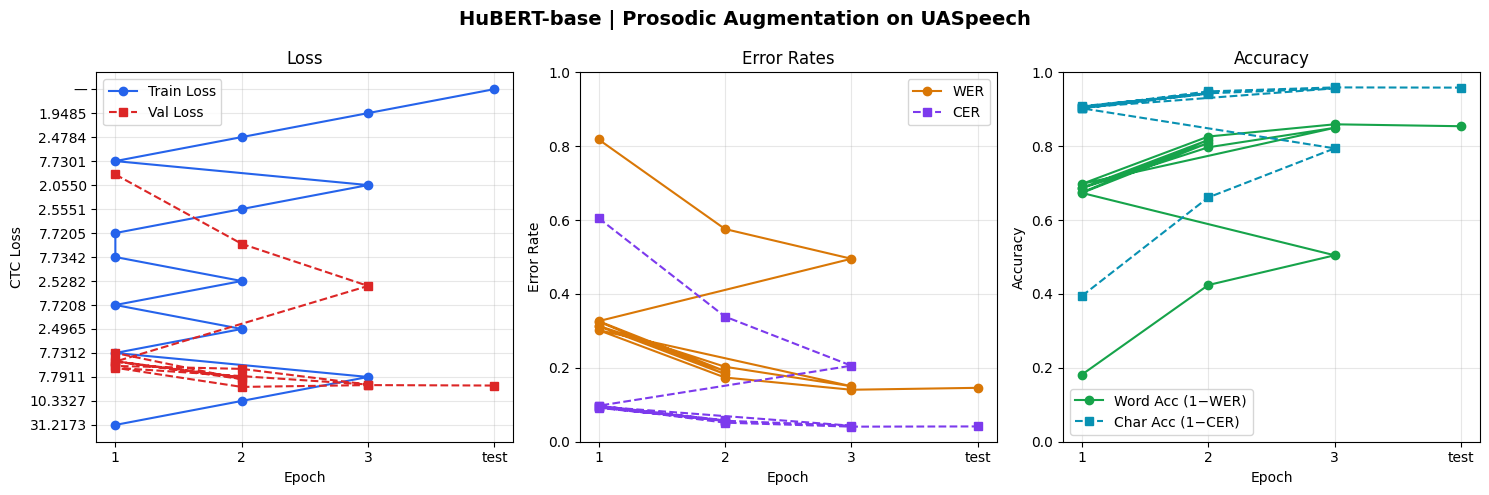

Saved → prosodic_training_curves.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("results.csv")
df["word_accuracy"] = 1 - df["wer"]
df["char_accuracy"] = 1 - df["cer"]
epochs = df["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("HuBERT-base | Prosodic Augmentation on UASpeech",
             fontsize=14, fontweight="bold")

axes[0].plot(epochs, df["train_loss"], "o-", label="Train Loss", color="#2563eb")
axes[0].plot(epochs, df["val_loss"],   "s--", label="Val Loss",  color="#dc2626")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].plot(epochs, df["wer"], "o-", label="WER", color="#d97706")
axes[1].plot(epochs, df["cer"], "s--", label="CER", color="#7c3aed")
axes[1].set_title("Error Rates"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Error Rate"); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[2].plot(epochs, df["word_accuracy"], "o-", label="Word Acc (1−WER)", color="#16a34a")
axes[2].plot(epochs, df["char_accuracy"], "s--", label="Char Acc (1−CER)", color="#0891b2")
axes[2].set_title("Accuracy"); axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy"); axes[2].set_ylim(0, 1)
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("prosodic_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → prosodic_training_curves.png")